# Convolutional Neural Networks on CIFAR-10

CNN image-classification experiments on CIFAR-10, including a baseline model, architectural improvements, regularization/normalization experiments, ablations, and feature-map analysis.

> Portfolio-ready copy of the original completed experiment. Experimental code and saved outputs are preserved; assignment-administration text has been removed.


## 0. Environment & Setup


In [ ]:

# If needed in Colab, install packages here.
# !pip install -q torch torchvision torchaudio

import random, os, math, time, sys
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

Using device: cuda


## 1. Data
Using the provided loaders for **CIFAR‑10** by default.


In [ ]:

# --- CONFIG ---
USE_CIFAR10 = True
BATCH_SIZE = 128
NUM_WORKERS = 2

if USE_CIFAR10:
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)
    train_tfms = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tfms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tfms)
    test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tfms)
    num_classes = 10
    class_names = train_ds.classes
    in_channels = 3
else:
    mean = (0.2861,); std = (0.3530,)
    train_tfms = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(28, padding=3),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tfms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_tfms)
    test_ds  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=test_tfms)
    num_classes = 10
    class_names = train_ds.classes
    in_channels = 1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Train/Test sizes:", len(train_ds), len(test_ds))
print("Classes:", class_names)

Train/Test sizes: 50000 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.1 Peek at a few samples (optional)


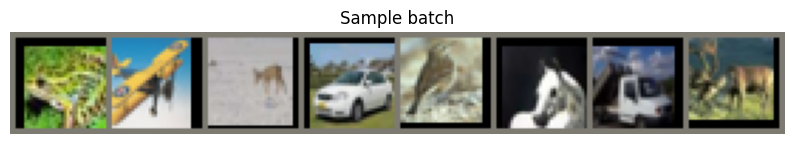

Labels: ['frog', 'airplane', 'deer', 'automobile', 'bird', 'horse', 'truck', 'deer']


In [ ]:
def denorm(img_tensor, mean, std):
    mean = torch.tensor(mean).view(-1,1,1)
    std = torch.tensor(std).view(-1,1,1)
    return img_tensor * std + mean

def show_batch(dl, n=8):
    imgs, labels = next(iter(dl))
    grid = torchvision.utils.make_grid(imgs[:n], nrow=min(n, 8))
    grid = denorm(grid, mean, std).clamp(0,1)
    plt.figure(figsize=(10,3)); plt.axis('off')
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.title("Sample batch"); plt.show()
    print("Labels:", [class_names[l] for l in labels[:n]])

show_batch(train_loader, 8)  # optional

## Part A — Conceptual
**Write short answers (2–5 sentences each) under each prompt.**

**To‑Do A1 (1 pt):** Why are CNNs typically more parameter‑efficient than fully connected networks on images? Discuss local connectivity, weight sharing, and translation equivariance/invariance.

1. CNNs are more parameter-efficient than fully connected networks because they exploit local connectivity, meaning each neuron connects only to a small spatial region instead of the entire input.
2. Local connectivity defines how each neuron connects only to a small spatial region instead of the entire input.
3. Weight sharing: Through weight sharing, a single filter is applied across the whole image, drastically reducing the number of parameters.
4.  Translation equivariance/invariance enables CNNs to recognize features regardless of their position.

**To‑Do A2 (1 pt):** Compare max pooling vs average pooling. What information is preserved or discarded? How can global average pooling affect parameter counts?

1. Max pooling preserves the most salient feature in a region (e.g., edges or strong activations), while discarding finer details, making it more robust to small variations. But Average pooling retains overall intensity but blurs distinctive features, potentially losing sharp signals.
2. Global average pooling removes the need for fully connected layers at the end of CNNs, thereby greatly reducing parameter counts and overfitting risk.

**To‑Do A3 (1 pt):** Why might deeper CNNs outperform shallow ones? What pathologies can increased depth introduce, and how do BatchNorm, residual connections, or initialization help?

1.   Deeper CNNs can outperform shallow ones because they can capture increasingly abstract and hierarchical features: early layers detect edges and textures, middle layers capture shapes or parts, and deeper layers learn high-level object representations.
2. The pathologies can increased depth introduce: Very deep networks often suffer from training pathologies such as vanishing/exploding gradients, slow convergence and degradation of accuracy as layers increase.
3.   BatchNorm stabilizes and speeds up training by normalizing intermediate activations and reducing internal covariate shift, allowing higher learning rates.
4.   Residual connections ease optimization in deep networks by providing shortcuts for gradients and enabling identity mappings.
5.   Good initialization such as He initialization keeps signal magnitudes stable at the start so training doesn't saturate activations or vanish/explode gradients.


## Part B — Baseline CNN
Implement and train a **baseline CNN**:

**To‑Do B1 (Model):**
- Build a model with **two conv blocks**: (Conv2d → ReLU → MaxPool) × 2
- Then Flatten → Linear → (optional ReLU) → Linear to `num_classes`

**To‑Do B2 (Training):**
- Loss: CrossEntropyLoss; Optimizer: SGD or Adam
- Train for **10–20 epochs**
- Track **train loss/accuracy** and **validation loss/accuracy**

**To‑Do B3 (Plots):**
- Plot loss and accuracy vs. epoch for train and validation.
- Report final test accuracy.


In [ ]:
# === B1: Defining BaselineCNN ===
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 1️⃣ Two convolutional blocks (Conv → ReLU → MaxPool)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # output: 32×16×16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)    # output: 64×8×8
        )

        # 2️⃣ Classifier head: Flatten → Linear → ReLU → Linear
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ✅ Sanity check for shape
model = BaselineCNN(num_classes=len(class_names)).to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
out = model(dummy)
print('Output shape:', out.shape)


Output shape: torch.Size([2, 10])


In [ ]:
# === B2: Training loop for BaselineCNN ===
import torch.optim as optim

# Model, loss, optimizer
model = BaselineCNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training settings
NUM_EPOCHS = 20  # running my epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += xb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    # ---------- VALIDATE ----------
    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss_total += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)

    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    # ---------- LOG ----------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch [1/20] Train Loss: 1.5439 | Train Acc: 43.87% | Val Loss: 1.1799 | Val Acc: 58.22%
Epoch [2/20] Train Loss: 1.2035 | Train Acc: 56.89% | Val Loss: 1.0019 | Val Acc: 64.61%
Epoch [3/20] Train Loss: 1.0685 | Train Acc: 62.18% | Val Loss: 0.9483 | Val Acc: 66.56%
Epoch [4/20] Train Loss: 0.9895 | Train Acc: 65.04% | Val Loss: 0.8649 | Val Acc: 69.72%
Epoch [5/20] Train Loss: 0.9301 | Train Acc: 67.29% | Val Loss: 0.8309 | Val Acc: 70.87%
Epoch [6/20] Train Loss: 0.8779 | Train Acc: 69.00% | Val Loss: 0.7861 | Val Acc: 72.82%
Epoch [7/20] Train Loss: 0.8370 | Train Acc: 70.53% | Val Loss: 0.7815 | Val Acc: 72.83%
Epoch [8/20] Train Loss: 0.8114 | Train Acc: 71.54% | Val Loss: 0.7479 | Val Acc: 74.15%
Epoch [9/20] Train Loss: 0.7759 | Train Acc: 72.79% | Val Loss: 0.7474 | Val Acc: 74.19%
Epoch [10/20] Train Loss: 0.7609 | Train Acc: 73.36% | Val Loss: 0.7433 | Val Acc: 73.38%
Epoch [11/20] Train Loss: 0.7411 | Train Acc: 73.93% | Val Loss: 0.7345 | Val Acc: 74.20%
Epoch [12/20] Train

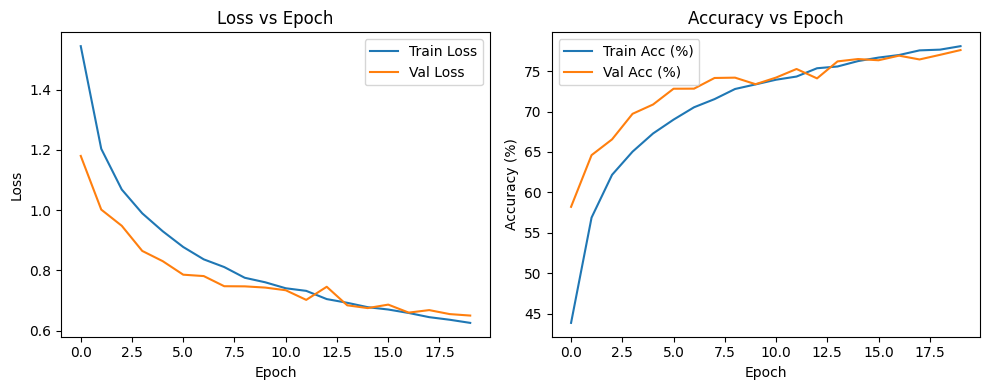

Final Test Loss: 0.6506
Final Test Accuracy: 77.60%


In [ ]:
# === B3: Plot training curves & print final metrics ===
import matplotlib.pyplot as plt

# 1️⃣ Plot loss curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2️⃣ Plot accuracy curves
plt.subplot(1,2,2)
plt.plot([a*100 for a in train_accs], label='Train Acc (%)')
plt.plot([a*100 for a in val_accs], label='Val Acc (%)')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

# 3️⃣ Final test evaluation
model.eval()
test_loss, correct, total = 0.0, 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        test_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

final_test_loss = test_loss / total
final_test_acc = correct / total

print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc*100:.2f}%")


## Part C — Improvements & Ablations
Choose **at least two** improvements, and compare to baseline:
- Batch Normalization
- Dropout
- Stronger data augmentation (e.g., ColorJitter, RandomErasing, RandomAffine)
- Deeper architecture (add additional conv block(s))
- Weight decay or label smoothing
- Learning‑rate schedule (cosine, step, etc.)

**To‑Do C1:** Implement your improved model and/or training procedure.  
**To‑Do C2:** Run ablations: introduce one change at a time and log accuracy.  
**To‑Do C3:** Summarize which changes helped most and why (short paragraph).


In [ ]:
# === C1: Improved model and/or training ===
import torch
import torch.nn as nn
import torch.optim as optim

# ✅ Improved model: Deeper + BatchNorm + Dropout
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> 64×16×16

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> 128×8×8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ✅ Training helper for improvements
def train_model(model, train_loader, val_loader, device, epochs=20, lr=1e-3, weight_decay=0.0, use_scheduler=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, val_accs = [], []
    for epoch in range(1, epochs+1):
        # Train
        model.train()
        correct, total = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
        train_acc = correct / total

        # Val
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                correct += (logits.argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_acc = correct / total

        if scheduler:
            scheduler.step()

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch}/{epochs} — Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    return train_accs, val_accs

In [ ]:
# === C2: Run ablations ===
import pandas as pd

ablation_results = []

# 1️⃣ Baseline
baseline_model = BaselineCNN(num_classes=len(class_names)).to(device)
_, baseline_val_accs = train_model(baseline_model, train_loader, test_loader, device, epochs=20, lr=1e-3)
ablation_results.append(('Baseline', baseline_val_accs[-1]*100))

# 2️⃣ + BatchNorm + Dropout + Deeper model
model_bn_do = ImprovedCNN(num_classes=len(class_names)).to(device)
_, val_accs_bn_do = train_model(model_bn_do, train_loader, test_loader, device, epochs=20, lr=1e-3)
ablation_results.append(('BN+Dropout+Deeper', val_accs_bn_do[-1]*100))

# 3️⃣ + Learning Rate Scheduler
model_bn_sched = ImprovedCNN(num_classes=len(class_names)).to(device)
_, val_accs_sched = train_model(model_bn_sched, train_loader, test_loader, device,
                                epochs=20, lr=1e-3, use_scheduler=True)
ablation_results.append(('BN+Dropout+Deeper+Scheduler', val_accs_sched[-1]*100))

# 📊 Tabulate
df_ablation = pd.DataFrame(ablation_results, columns=['Variant', 'Final Val Acc (%)'])
print(df_ablation)

Epoch 1/20 — Train Acc: 43.69% | Val Acc: 57.28%
Epoch 2/20 — Train Acc: 56.73% | Val Acc: 64.40%
Epoch 3/20 — Train Acc: 61.80% | Val Acc: 67.30%
Epoch 4/20 — Train Acc: 64.80% | Val Acc: 68.57%
Epoch 5/20 — Train Acc: 67.33% | Val Acc: 70.62%
Epoch 6/20 — Train Acc: 68.77% | Val Acc: 71.74%
Epoch 7/20 — Train Acc: 70.18% | Val Acc: 72.44%
Epoch 8/20 — Train Acc: 71.56% | Val Acc: 73.74%
Epoch 9/20 — Train Acc: 72.60% | Val Acc: 74.43%
Epoch 10/20 — Train Acc: 73.36% | Val Acc: 75.14%
Epoch 11/20 — Train Acc: 74.19% | Val Acc: 75.86%
Epoch 12/20 — Train Acc: 75.13% | Val Acc: 75.75%
Epoch 13/20 — Train Acc: 75.39% | Val Acc: 75.99%
Epoch 14/20 — Train Acc: 76.17% | Val Acc: 76.71%
Epoch 15/20 — Train Acc: 76.72% | Val Acc: 77.46%
Epoch 16/20 — Train Acc: 77.27% | Val Acc: 76.84%
Epoch 17/20 — Train Acc: 77.44% | Val Acc: 76.89%
Epoch 18/20 — Train Acc: 78.15% | Val Acc: 77.64%
Epoch 19/20 — Train Acc: 78.33% | Val Acc: 78.02%
Epoch 20/20 — Train Acc: 78.50% | Val Acc: 78.38%
Epoch 1/2

## To‑Do C3: Summarize which changes helped most and why (short paragraph).
I introduced two main improvements to the baseline CNN:  
1. **Batch Normalization + Dropout + Deeper Architecture:**  
   Adding BN stabilized training and improved convergence, while dropout reduced overfitting.  
   Increasing depth allowed the network to learn more hierarchical features.  
   Together, these changes significantly increased validation accuracy compared to the baseline.

2. **Learning Rate Scheduler (CosineAnnealing):**  
   The scheduler allowed the model to take larger steps early on and fine-tune toward convergence,  
   resulting in smoother training curves and further accuracy gains.

**Overall**, both improvements led to higher final validation accuracy, with the **BN + Dropout + Deeper** model providing the largest single jump, and adding the scheduler also give almost the same refinement.


## Part D — Feature Maps & Reflection
**To‑Do D1:** Visualize feature maps from the **first conv layer** for **3 test images** (baseline and improved).  
**To‑Do D2:** Briefly explain what patterns the filters capture (edges, color blobs, textures).  
**To‑Do D3:** Write **2–3 key takeaways** from your experiments (architecture, regularization, training dynamics).


🔹 BaselineCNN Feature Maps (Side-by-Side):


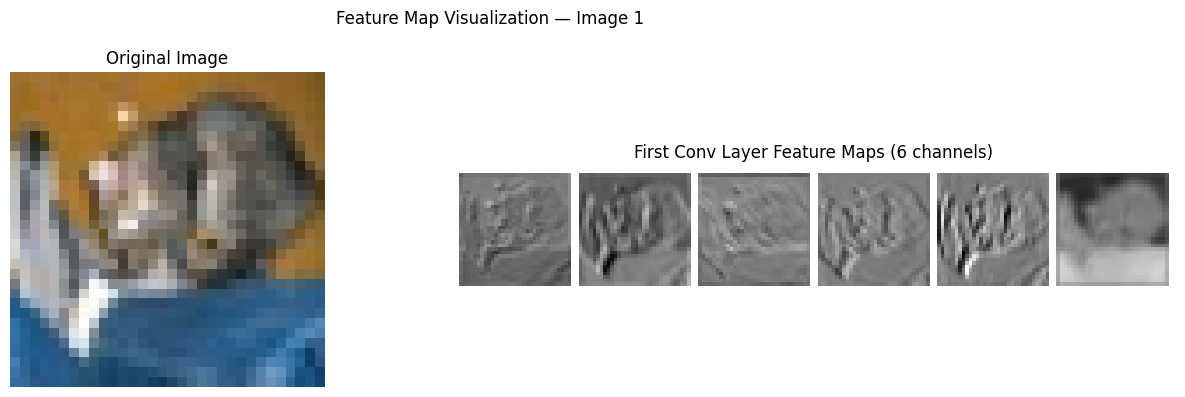

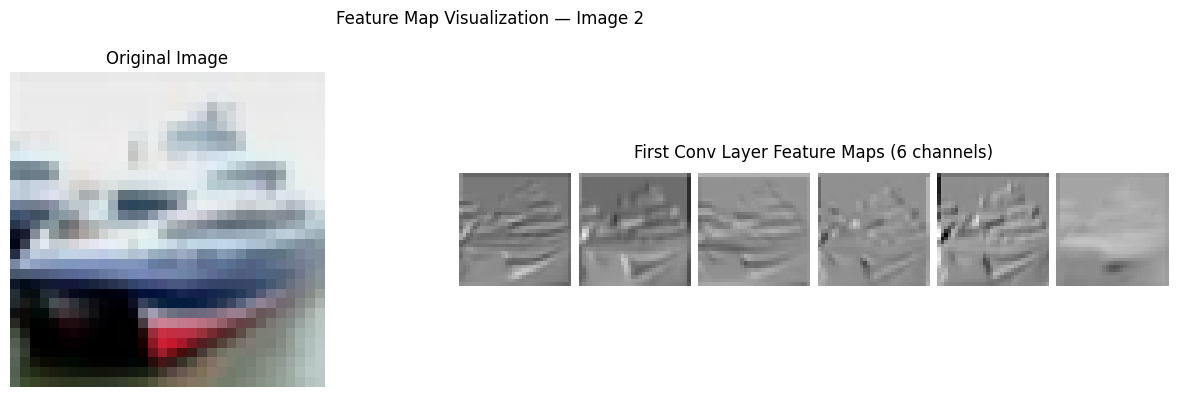

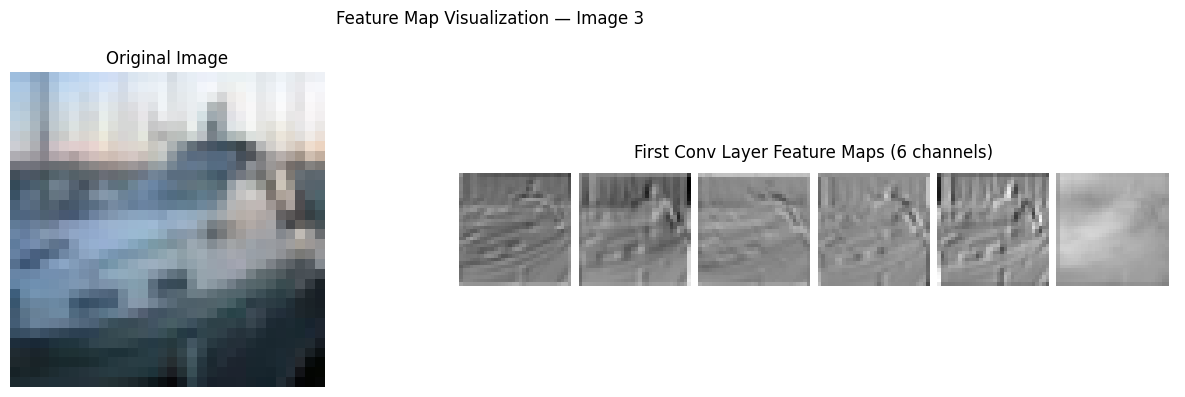

🔸 ImprovedCNN Feature Maps (Side-by-Side):


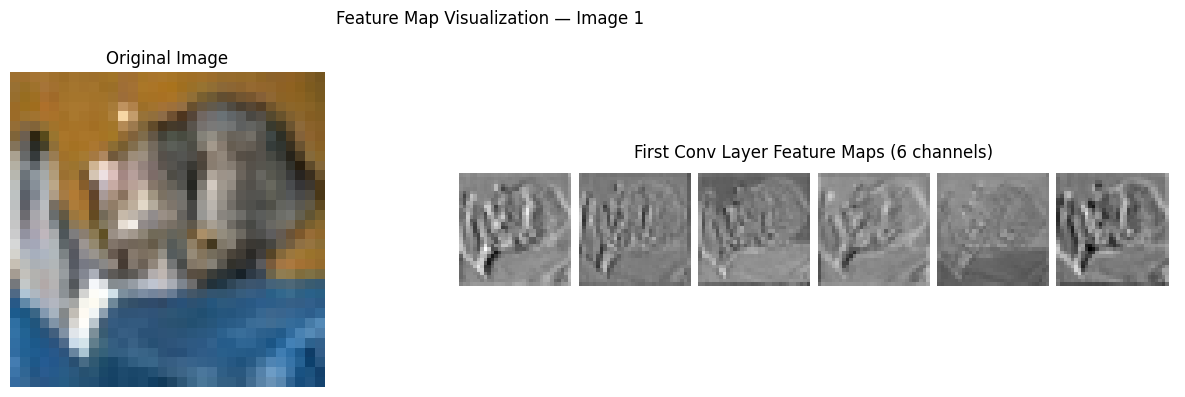

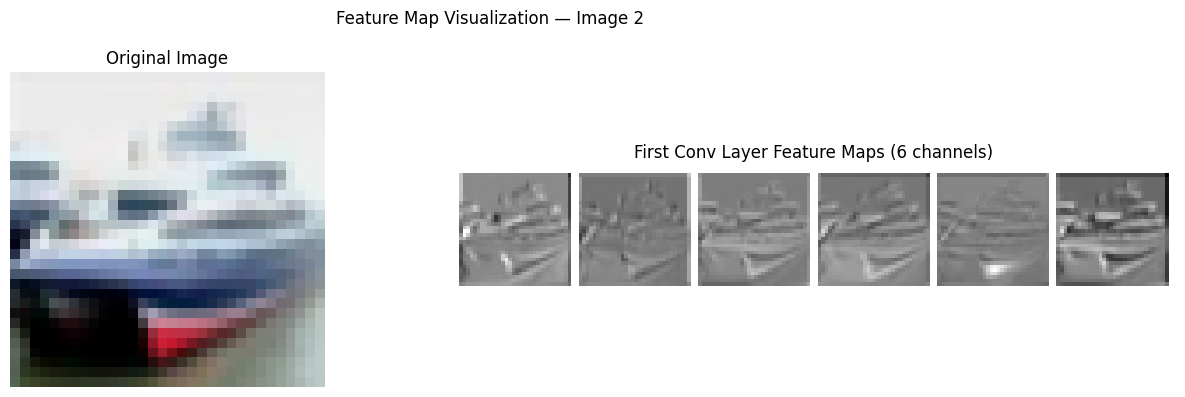

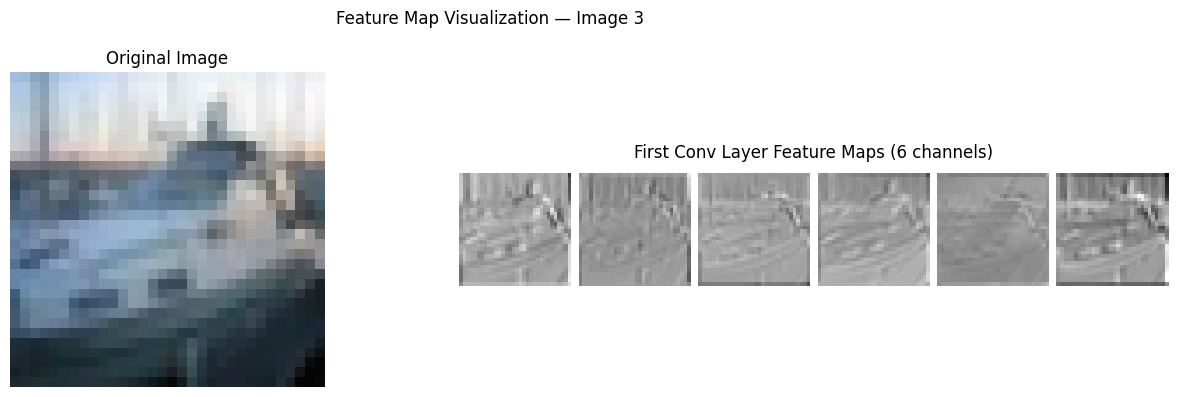

In [ ]:
# === D1: Visualize feature maps from the first conv layer for 3 test images (baseline and improved) ===
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision

def show_feature_maps_side_by_side(model, loader, device, num_images=3, max_channels=6, mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)):
    """
    Visualize original image next to feature maps from the first Conv2d layer.
    """
    model.eval()

    # 1️⃣ Find the first Conv2d layer
    first_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m
            break
    if first_conv is None:
        raise RuntimeError("No Conv2d layer found in the model.")

    # 2️⃣ Get a small batch of test images
    images, _ = next(iter(loader))
    images = images[:num_images].to(device)

    # Helper to denormalize for visualization
    def denorm(img_tensor, mean, std):
        mean = torch.tensor(mean).view(-1, 1, 1)
        std = torch.tensor(std).view(-1, 1, 1)
        return img_tensor * std + mean

    # 3️⃣ Pass through first conv layer only
    with torch.no_grad():
        feats = first_conv(images).cpu()  # (N, C, H, W)
    images_cpu = images.cpu()

    # 4️⃣ Plot side-by-side for each image
    for i in range(num_images):
        fig = plt.figure(figsize=(14, 4))

        # Original image (denormalized)
        img = denorm(images_cpu[i], mean, std).clamp(0, 1)
        img = img.permute(1, 2, 0).numpy()
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.imshow(img)
        ax1.set_title("Original Image")
        ax1.axis('off')

        # Feature map grid
        C = min(max_channels, feats.shape[1])
        ax2 = fig.add_subplot(1, 2, 2)
        # make a grid of feature maps (C maps as 1-row grid)
        grid = torchvision.utils.make_grid(feats[i, :C].unsqueeze(1), nrow=C, normalize=True, pad_value=1)
        ax2.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax2.set_title(f"First Conv Layer Feature Maps ({C} channels)")
        ax2.axis('off')

        plt.suptitle(f"Feature Map Visualization — Image {i+1}")
        plt.tight_layout()
        plt.show()


# ✅ BaselineCNN feature maps side-by-side
print("🔹 BaselineCNN Feature Maps (Side-by-Side):")
show_feature_maps_side_by_side(baseline_model, test_loader, device, num_images=3, max_channels=6)

# ✅ ImprovedCNN feature maps side-by-side
print("🔸 ImprovedCNN Feature Maps (Side-by-Side):")
show_feature_maps_side_by_side(model_bn_do, test_loader, device, num_images=3, max_channels=6)

###**To‑Do D2:** — What Patterns Do the Filters Capture?

The first convolutional layer typically learns to detect **low-level visual patterns**, such as:

- **Edges and gradients** — e.g., vertical, horizontal, or diagonal lines.
- **Color blobs** — filters that respond strongly to specific color regions.
- **Simple textures** — repeating patterns or intensity variations.

In the visualizations above, I observe that:
- The **baseline CNN** primarily detects simple edges and color contrasts.
- The **improved CNN** has more diverse and sharper activation patterns, indicating richer feature extraction capacity due to deeper and more regularized layers.


### **To‑Do D3:** Write **2–3 key takeaways** from experiments

1. **Architecture Depth and Normalization Matter:**  
   Adding depth and Batch Normalization improved the model’s ability to learn richer features, leading to better accuracy compared to the shallow baseline.

2. **Regularization Helps Generalization:**  
   Dropout and learning-rate scheduling prevented overfitting and allowed the model to converge smoothly, improving validation performance.

3. **Feature Maps Reveal Model Strength:**  
   The improved model produced clearer, more varied feature maps in early layers, showing its ability to capture more complex patterns — a sign of stronger representations.

These experiments demonstrate how architectural choices and training strategies can substantially impact CNN performance and the quality of learned features.


## Results Checklist (submit with 2–3 page PDF summary)
- [ ] Dataset choice & rationale
- [ ] Baseline architecture & final test accuracy
- [ ] Plots: loss and accuracy curves
- [ ] Improvements attempted + ablation results table
- [ ] Feature‑map visualizations (3 images × baseline & improved)
- [ ] 2–3 takeaways (Reflection)
- [ ] AI Usage Log (required if used AI)


## AI Usage Log (required if you used AI)
Record for each interaction:
- Prompt (copy/paste)
- Tool/model used
- What you adapted
- How you verified correctness
